In [16]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as curve_fit
import pandas as pd
import numpy as np

# Ajuste a grafica "stoping powers"

A partir de la gráfica adjunta de “stopping Powers” ( dE/dx ) de protones en Silicio, encuentre una relación que
permita obtener el valor de ( dE/dx ) en función de la energía E de los protones.
Puede ser una tabla “E”_vs_“dE/dx” y hacer un ajuste de un polinomio de grado 2 para hallar ( dE/dx ) para
cualquier valor de E

In [2]:
from utilities.ajuste  import ajuste_stopping_power, modelo

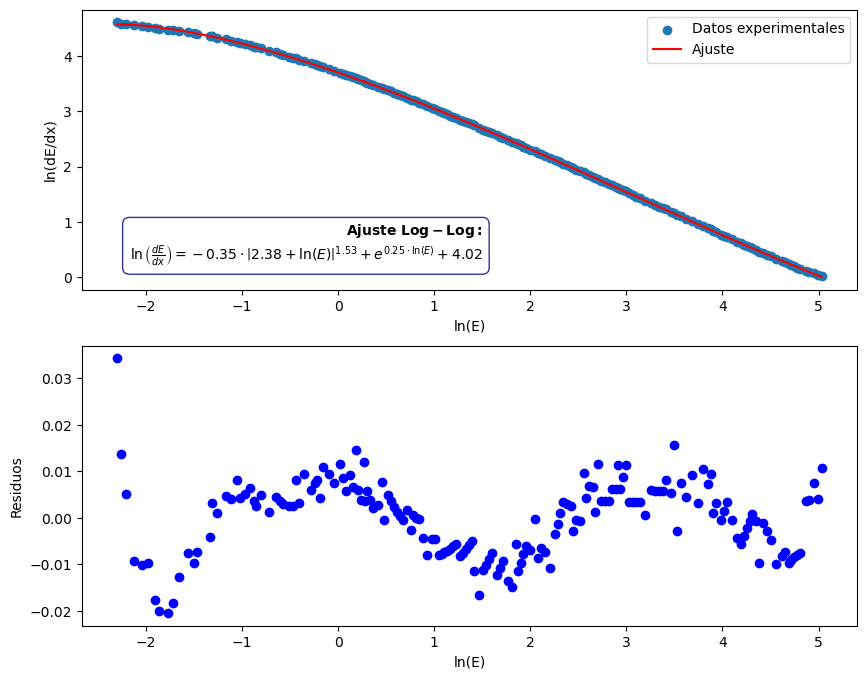

In [7]:
fig, model_data = ajuste_stopping_power()

el modelo resulta ser 
$$
\ln \left (\frac{dE}{dx}[KeV]\right) = -0.35\cdot |2.38 + \ln(E[Mev])|^{1.53} + e^{0.25\cdot \ln (E)}+4.02
$$

In [14]:
def model_predictor(E, model_data = model_data):
    list_ln_E = np.log(E)
    ln_dE_dx = np.zeros(len(list_ln_E))
    for i in range(len(list_ln_E)):
        ln_dE_dx[i] = modelo(list_ln_E[i], *model_data[0])

    return ln_dE_dx

# Calculo numerico del alcanze de protones en silicio

Realice un cálculo numérico de los protones avanzando en el Silicio por pasos de espesor deltaX muy pequeño:
Se va avanzando en la profundidad X alcanzada por pasos deltaX:
Profundidad X nueva = Profundidad X anterior + deltaX
En esa nueva profundidad X determinamos la energía:
(Energía nueva) = (Energía anterior) – (dE/dx)*deltaX.
El valor de (dE/dx) es el que corresponde a la (Energía anterior).
Guarde en un arreglo el par de datos: {profundidad X actual, deltaE=(dE/dx)*deltaX}
Se repite avanzando en la profundidad X hasta que la (Energía nueva) sea menor o igual a cero.
Cuando se alcance energía cero, o menor, el valor de la profundidad X es el alcance R (range). Dé esto como
respuesta b.

In [22]:
# Euler simulation – proton range in silicon
# model_predictor returns ln(dE/dx)  with dE/dx in keV/mm,  E in MeV
# Euler step:  E_new [MeV] = E [MeV]  -  (dE/dx [keV/mm] * dx [mm]) / 1000

dx   = 0.01   # mm
E    = 100.0  # MeV
x    = 0.0    # mm

x_list    = [x]
E_list    = [E]
dEdx_list = []

while E >= 1.0:
    dEdx_keV_mm = np.exp(model_predictor(np.array([E]))[0])  # keV/mm
    dE_MeV      = dEdx_keV_mm * dx                 # MeV lost in this step
    E            = E - dE_MeV
    x            = x + dx
    dEdx_list.append(dEdx_keV_mm)
    x_list.append(x)
    E_list.append(E)

x_arr    = np.array(x_list)
E_arr    = np.array(E_list)
dEdx_arr = np.array(dEdx_list)

range_R = x_arr[-1]

print(f"Range R = {range_R:.2f} mm")

Range R = 41.91 mm


In [ ]:


fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axs[0].plot(x_arr, E_arr, color='steelblue')
axs[0].set_ylabel('E (MeV)')
axs[0].set_title(r'Euler – proton energy vs depth in Si  ($E_0 = 100$ MeV)')
axs[0].grid(True)

axs[1].plot(x_arr[:-1], dEdx_arr, color='firebrick')
axs[1].set_xlabel('Depth x (mm)')
axs[1].set_ylabel('dE/dx (keV/mm)')
axs[1].set_title('Stopping power vs depth (Bragg curve)')
axs[1].axvline(range_R, color='k', linestyle='--', label=f'R = {range_R:.2f} mm')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()